# 02. Fahy & Gardonio's coupled box

The worked example of **Fahy & Gardonio, *Sound and Structural Vibration*,
2nd ed.**, geometry and mesh both theirs. The same two lists, uncoupled and
coupled, compared by frequency and by mode shape.

| | |
|---|---|
| cavity | 0.414 × 0.314 × 0.360 m, air, five hard walls |
| plate | `z = 0.360` m, 1 mm aluminium, $\rho = 2700$ kg m⁻³, $E = 7.1\times10^{10}$ N m⁻², clamped all round |
| mesh | 16 × 16 × 8 `CHEXA8` + 16 × 16 `CQUAD4F`, conforming |
| method | coupled modal analysis, $\mathbf K\mathbf x = \omega^2\mathbf M\mathbf x$ |
| quoted | 9 uncoupled plate modes, 18 coupled modes |


---
## 1. The run

Nothing is defined in this notebook: `from pycafe import *` is the whole
import.

The plate is written out as a `Structure` rather than `aluminium(...)`
because the book's modulus is $7.1\times10^{10}$ N m⁻², not pyCAFE's default
70 GPa. Poisson's ratio is not quoted in the example; 0.33 is used.


In [1]:
%matplotlib widget
# every figure below is a live canvas that can be turned with the mouse
# (needs ipympl); drop this line for flat pictures instead.

import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))                 # run from examples/

import numpy as np
import matplotlib.pyplot as plt

from pycafe import *          # the whole API: models, questions, solvers, plots

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

ANALYSIS = "vibroacoustic"                 # fluid and structure, coupled
FLUID = AIR

# Fahy & Gardonio's aluminium: rho = 2700 kg/m3, E = 7.1e10 N/m2, h = 1 mm,
# clamped on all four edges. nu is not given in the example; 0.33 is used.
STRUCTURE = Structure(t=1.0e-3, E=7.1e10, nu=0.33, rho_s=2700.0,
                      name="aluminium", support="clamped")

F_MAX = 500.0        # what the mesh is checked against
N_MODES = 18         # coupled modes, as in the book
N_PLATE = 9          # uncoupled plate modes quoted, as in the book

# The eighteen reach 587 Hz, past the ninth plate mode, so the uncoupled
# lists used to identify them run further than the nine the book tabulates.
N_BASIS_S = 15
N_BASIS_A = 9

RHO0, C0 = FLUID.rho0, FLUID.c0
print(f"{ANALYSIS} run in {FLUID.name}, c0 = {C0:.0f} m/s")
print(f"plate: {STRUCTURE.name}, {STRUCTURE.t * 1e3:.1f} mm, "
      f"{STRUCTURE.support}, E = {STRUCTURE.E:.3g} Pa, nu = {STRUCTURE.nu}, "
      f"rho = {STRUCTURE.rho_s:.0f} kg/m3")
print(f"       D = {STRUCTURE.D:.3f} N m, "
      f"mass = {STRUCTURE.rho_s * STRUCTURE.t:.2f} kg/m2")

vibroacoustic run in air, c0 = 343 m/s
plate: aluminium, 1.0 mm, clamped, E = 7.1e+10 Pa, nu = 0.33, rho = 2700 kg/m3
       D = 6.640 N m, mass = 2.70 kg/m2


---
## 2. The geometry

**Not asked.** One file, named here: `Library/cavity_plate_FG.msh`, the
book's box cut with the book's element counts. The other notebooks open a
dialog on `../Library/`; this one cannot, because the frequencies below are
quoted against this mesh and no other.

That is also why the element counts are pinned in `Library/make_library.py`
instead of following from `f_max` as they do everywhere else. The mesh is
conforming: the plate quadrilaterals are the top faces of the fluid
hexahedra.


MeshFile -> cavity_plate_FG.msh
  volume   fluid           2601 nodes
  surface  plate            289 nodes
  surface  rigid_walls      801 nodes
  edge     plate_clamp       64 nodes


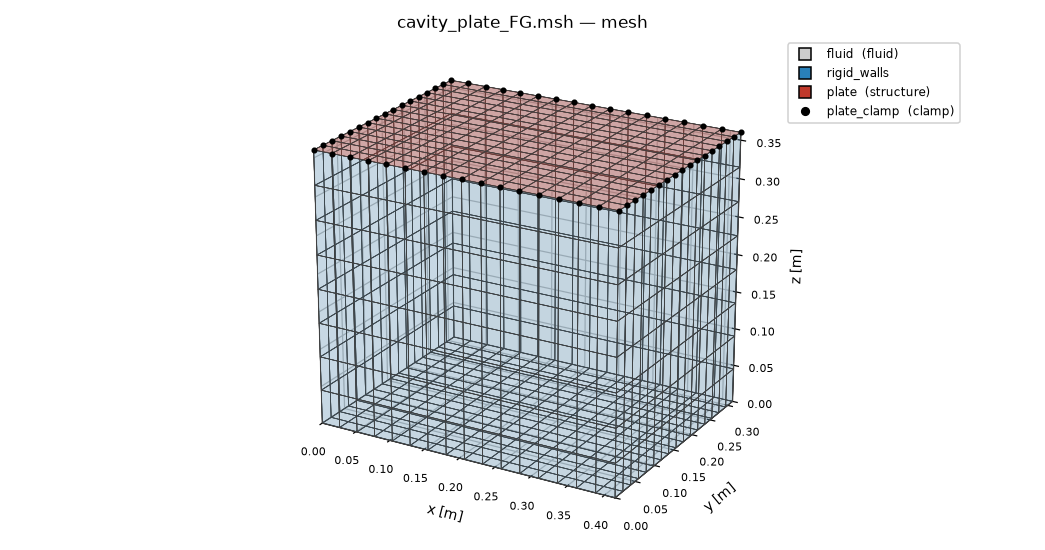

<Axes3D: title={'center': 'cavity_plate_FG.msh — mesh'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [2]:
geometry = MeshFile(os.path.join("..", "Library", "cavity_plate_FG.msh"))
picked = os.path.abspath(str(geometry.path))
print(type(geometry).__name__, "->", os.path.basename(picked))

nodes, elements, boundaries, groups = load_mesh_with_groups(picked,
                                                            verbose=False)
for name, group in sorted(groups.items(), key=lambda kv: -kv[1]["dim"]):
    kind = {3: "volume", 2: "surface", 1: "edge"}.get(group["dim"], "?")
    print(f"  {kind:<8} {name:<14} {len(group['nodes']):5d} nodes")

plot_mesh_3d(nodes, groups, title=f"{os.path.basename(picked)} — mesh")

---
## 3. The model

`build_model` reads the mesh, checks it against `f_max`, draws it by role and
assembles both domains and the coupling matrix.

Two lines of the report matter: *interface conforming*, which is the licence
for everything below, and the element size. The fluid is good to ~590 Hz; the
plate is the tighter rule, six elements per bending wavelength only to about
410 Hz, so the top of the eighteen is resolved more coarsely than the bottom.
That is a property of the book's mesh, and is why it is kept.


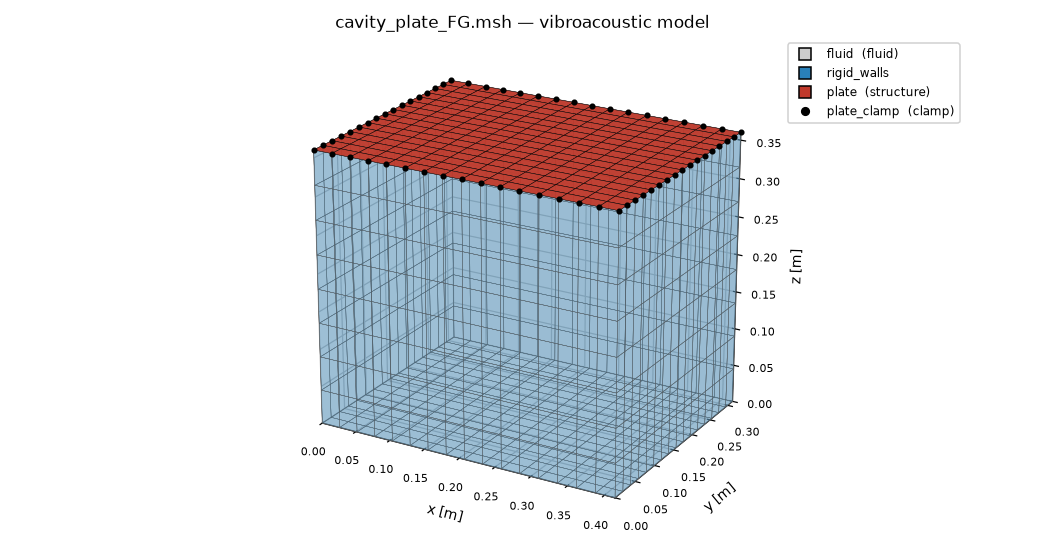

..\Library\cavity_plate_FG.msh  (vibroacoustic analysis)
--------------------------------------------------------
  2601 nodes, 64 x Line 2, 1024 x Quadrilateral 4, 2048 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 256 faces, one fluid element behind each
  · fluid element size: 45.0 / 45.0 / 45.0 mm (min / mean / max)
  · good to ~1% up to 586 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 500 Hz: 15.2 elements per wavelength, dispersion error ~0.71%
  · selectable boundaries: rigid_walls
  => usable
domains in cavity_plate_FG.msh (vibroacoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure   group 'plate'          <- aluminium: t = 1.00 mm, E = 71 GPa, nu = 0.33, rho = 2700.0 kg/m3
  support     group 'plate_clamp'    <- clamped (the mesh says which nodes are held, Structure.support says how)
  selectable boundaries: rigid_walls

plate      0.414 x 0.314 m 

In [3]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,
    fluid=FLUID,
    structure=STRUCTURE,
    f_max=F_MAX,
    work_dir=".",
)
model = build_model(spec)

nodes = model["nodes"]
elements = model["elements"]
groups = model["groups"]
boundaries = model["boundaries"]
system = model["system"]
report = model["report"]

print(report)
print(describe_domains(report, FLUID, STRUCTURE))

# Where the plate is and how its nodes are laid out: measured, not assumed.
panel = describe_panel(nodes, groups[report.roles["structure"]]["nodes"])
BOX = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
LX, LY, LZ = (a[-1] - a[0] for a in BOX)

print(f"\nplate      {panel}")
print(f"cavity     {LX:.3f} x {LY:.3f} x {LZ:.3f} m"
      f"   (Fahy & Gardonio: 0.414 x 0.314 x 0.360 m)")
print(f"unknowns   {system['structural']['idx_free'].size} structural + "
      f"{system['acoustic']['nodes0'].size} acoustic")

---
## 4. Uncoupled: the two halves on their own

`build_cms_basis` solves both component problems with the other domain
absent — the plate **in vacuo**, and the **sealed** hard-walled cavity.
These are the frequencies and the shapes section 6 measures against.

The plate is checked against Warburton (1954), a Rayleigh solution and so an
upper bound; the cavity against
$f_{lmn} = \frac{c_0}{2}\sqrt{(l/L_x)^2+(m/L_y)^2+(n/L_z)^2}$, which is exact.
Nine plate modes are printed, as in the book. `(1,3)` comes out 6% high:
three half-waves across the 0.314 m side leave about five elements each.

The sealed cavity's first entry is $f = 0$ — a uniform pressure in a closed
box costs no energy — and its first real mode is at 414 Hz, above the first
nine plate modes. This box is plate-controlled at the bottom of the range.


In [4]:
components = build_cms_basis(system, num_structural=N_BASIS_S,
                             num_acoustic=N_BASIS_A)

f_plate = components["omegas_s"] / (2 * np.pi)      # plate in vacuo
f_cavity = components["omegas_a"] / (2 * np.pi)     # hard-walled, sealed cavity

# order=6 so that (4,1) is in the running: on a 0.414 x 0.314 m plate it
# falls inside the first nine, and stopping at m, n <= 3 would miss it.
warburton = clamped_plate_modes(*panel.sides, STRUCTURE, num=N_PLATE, order=6)
analytic = rectangular_cavity_modes(C0, LX, LY, LZ, num=f_cavity.size - 1,
                                    skip_zero=True)

print("plate in vacuo, clamped all round — the book's first nine")
print(f"  {'mode':>4} {'pyCAFE [Hz]':>12} {'Warburton [Hz]':>15}"
      f" {'(m,n)':>7} {'error':>8}")
for i, (f_num, (f_ref, mn)) in enumerate(zip(f_plate[:N_PLATE], warburton),
                                         start=1):
    print(f"  {i:4d} {f_num:12.2f} {f_ref:15.2f} {str(mn):>7}"
          f" {(f_num / f_ref - 1) * 100:7.1f}%")
print(f"  and {f_plate.size - N_PLATE} more kept as a reference list, up to "
      f"{f_plate[-1]:.0f} Hz")

print("\nhard-walled sealed cavity")
print(f"  {'mode':>4} {'pyCAFE [Hz]':>12} {'exact [Hz]':>15} {'(l,m,n)':>9}"
      f" {'error':>8}")
print(f"  {1:4d} {f_cavity[0]:12.2f} {0.0:15.2f} {'(0,0,0)':>9}"
      f" {'—':>8}   uniform pressure, no energy")
for i, (f_num, (f_ref, lmn)) in enumerate(zip(f_cavity[1:], analytic),
                                          start=2):
    print(f"  {i:4d} {f_num:12.2f} {f_ref:15.2f} {str(lmn):>9}"
          f" {(f_num / f_ref - 1) * 100:7.1f}%")

plate in vacuo, clamped all round — the book's first nine
  mode  pyCAFE [Hz]  Warburton [Hz]   (m,n)    error
     1        73.01           73.43  (1, 1)    -0.6%
     2       124.91          124.31  (2, 1)     0.5%
     3       171.95          172.10  (1, 2)    -0.1%
     4       213.63          207.82  (3, 1)     2.8%
     5       219.78          219.17  (2, 2)     0.3%
     6       303.14          298.17  (3, 2)     1.7%
     7       325.70          321.70  (4, 1)     1.2%
     8       341.43          322.04  (1, 3)     6.0%
     9       374.19          367.78  (2, 3)     1.7%
  and 6 more kept as a reference list, up to 592 Hz

hard-walled sealed cavity
  mode  pyCAFE [Hz]      exact [Hz]   (l,m,n)    error
     1         0.00            0.00   (0,0,0)        —   uniform pressure, no energy
     2       414.92          414.25 (1, 0, 0)     0.2%
     3       479.46          476.39 (0, 0, 1)     0.6%
     4       547.06          546.18 (0, 1, 0)     0.2%
     5       634.06         

---
## 5. What ties them: $\mathbf K_c$

$$ \mathbf K_c = \int_S \mathbf N_s^{T}\,\mathbf n\,\mathbf N_a\,\mathrm dS $$

one row per structural DOF, one column per fluid node, read both ways:
$\mathbf K_c\mathbf p$ is the pressure loading the plate,
$\rho_0\mathbf K_c^{T}\ddot{\mathbf w}$ the plate driving the air. Nothing
else passes between the domains.

**The check.** Summed over the structural translations along one axis, a
column of $\mathbf K_c$ is $\int_S\mathbf n\,\mathrm dS$: zero along $x$ and
$y$, the plate area along $z$. It comes out a little under
$0.414\times0.314 = 0.130$ m² because the clamped rim has no free DOF. Far
off, or area on the wrong axis, means the plate is on the wrong face or its
normal points inwards.

**The picture.** $\mathbf A = \mathbf \Phi_s^{T}\mathbf K_c\mathbf \Phi_a$ in
the uncoupled shapes of section 4: $A_{ij}$ is how well plate mode $i$ pushes
the air the way cavity mode $j$ wants. Modes talk only to their own symmetry.
The first column is the sealed box's uniform pressure — the air spring — and
a bright entry there says that plate mode changes the cavity volume and will
be stiffened by it. It is the column that predicts section 6.


interface  256 faces, mean normal [0. 0. 1.]
Kc         (15606, 2601), 7203 non-zeros
column sum [0.       0.       0.114254] m2 over the free DOFs, of 0.130 m2 of plate
           the missing 0.0157 m2 is the share of the 64 clamped nodes,
           which carry no free DOF and therefore no column here


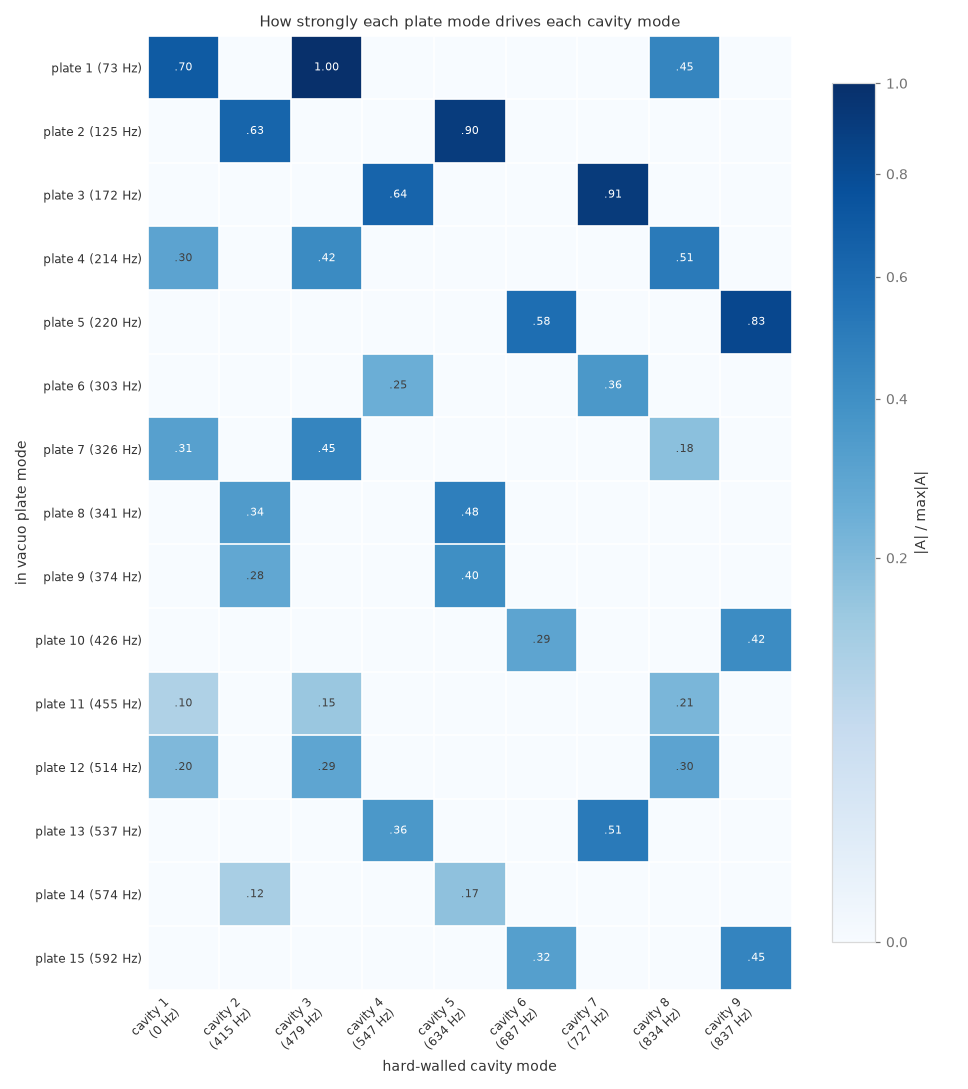

<Axes: title={'center': 'How strongly each plate mode drives each cavity mode'}, xlabel='hard-walled cavity mode', ylabel='in vacuo plate mode'>

In [5]:
coupling = system["coupling"]
interface = system["interface"]
Kc = coupling["Kc"]

# The vector area of the interface, read off the coupling matrix.
idx_s = system["structural"]["idx_free"]
area = np.zeros(3)
for axis in range(3):
    rows = np.where(idx_s % 6 == axis)[0]
    area[axis] = np.asarray(Kc[idx_s[rows]].sum(axis=0)).ravel().sum()

print(f"interface  {interface['conn0'].shape[0]} faces, "
      f"mean normal {np.round(interface['normals'].mean(axis=0), 12)}")
print(f"Kc         {Kc.shape}, {Kc.nnz} non-zeros")
held = len(groups[report.roles["clamp"]]["nodes"])
print(f"column sum {np.round(area, 6)} m2 over the free DOFs, "
      f"of {panel.area:.3f} m2 of plate")
print(f"           the missing {panel.area - area[panel.normal]:.4f} m2 is the "
      f"share of the {held} clamped nodes,\n"
      "           which carry no free DOF and therefore no column here")

A = np.abs(components["modal_coupling"])
plot_matrix(A, title="How strongly each plate mode drives each cavity mode",
            label="|A| / max|A|",
            row_labels=[f"plate {i + 1} ({f:.0f} Hz)"
                        for i, f in enumerate(f_plate)],
            col_labels=[f"cavity {j + 1}\n({f:.0f} Hz)"
                        for j, f in enumerate(f_cavity)],
            xlabel="hard-walled cavity mode", ylabel="in vacuo plate mode",
            show=True)

---
## 6. Coupled: the eighteen

$$
\mathbf K = \begin{bmatrix}\mathbf K_s & -\mathbf K_c\\ \mathbf 0 & \mathbf K_a\end{bmatrix},
\qquad
\mathbf M = \begin{bmatrix}\mathbf M_s & \mathbf 0\\ \rho_0\mathbf K_c^{T} & \mathbf M_a\end{bmatrix},
\qquad \mathbf K\mathbf x = \omega^{2}\mathbf M\mathbf x .
$$

The sealed cavity's 0 Hz mode survives the coupling and is **dropped here**:
it is a static bulge, not a vibration. The eighteen listed are the eighteen
flexible ones.

**How the two lists are matched.** By **shape**, never by order: each
uncoupled mode of section 4 is projected on the coupled ones, and the coupled
mode carrying it is the match. Read side by side, the lists would blame the
air for what is only a swap — the coupled mode carrying the first plate mode
is the first, but the one carrying the tenth is the eleventh.

**What the frequencies do.** The trapped air is a spring across the plate:
the mode that compresses it most, the single bulge, goes **up** by 13%.
Modes with a nodal line move air from one side to the other without
compressing it and drift **down** a percent or so, the air riding along as
added mass. The cavity modes move by about a percent the other way.


In [6]:
blocks = build_coupled_blocks(system)          # hard walls: nothing is added

t0 = time.time()
# One extra mode is asked for, because the 0 Hz uniform pressure is about to
# be dropped and the book's count is eighteen flexible modes.
f_all, shapes_all = solve_vibroacoustic_modal(system, num_modes=N_MODES + 1,
                                              blocks=blocks)
flexible = np.where(f_all > 1.0)[0][:N_MODES]
f_coupled = f_all[flexible]
shapes_coupled = np.real(shapes_all[:, flexible])

print(f"{f_coupled.size} coupled modes in {time.time() - t0:.2f} s, "
      f"{blocks['n_s']} structural + {blocks['n_a']} acoustic unknowns "
      f"(the 0 Hz uniform pressure dropped)")
for i, f in enumerate(f_coupled, start=1):
    print(f"  mode {i:2d}   {f:9.2f} Hz")

# Which coupled mode carries which uncoupled one, by shape and not by order.
n_s, n_a = blocks["n_s"], blocks["n_a"]
m_s, m_a = components["num_structural"], components["num_acoustic"]
Phi_s = components["Phi_R"][:n_s, :m_s]
Phi_a = components["Phi_R"][n_s:, m_s:m_s + m_a]
carried_s = np.abs(Phi_s.T @ (blocks["Ms"] @ shapes_coupled[:n_s]))
carried_a = np.abs(Phi_a.T @ (blocks["Ma"] @ shapes_coupled[n_s:]))

print("\nplate in vacuo -> coupled, paired by shape")
print(f"  {'plate mode':>10} {'in vacuo':>10} {'coupled mode':>13}"
      f" {'coupled':>10} {'shift':>9}")
for j, f_vacuo in enumerate(f_plate):
    k = int(np.argmax(carried_s[j]))
    print(f"  {j + 1:10d} {f_vacuo:9.2f} {k + 1:13d} {f_coupled[k]:10.2f} "
          f"{(f_coupled[k] / f_vacuo - 1) * 100:+8.1f}%")

# Only the sealed modes inside the range the eighteen cover: one above the
# last coupled frequency has no partner, and a best match would be invented.
print("\nsealed cavity -> coupled, paired by shape")
print(f"  {'cavity mode':>11} {'sealed':>10} {'coupled mode':>13}"
      f" {'coupled':>10} {'shift':>9}")
for j, f_hard in enumerate(f_cavity):
    if f_hard < 1.0 or f_hard > f_coupled[-1]:
        continue
    k = int(np.argmax(carried_a[j]))
    print(f"  {j + 1:11d} {f_hard:9.2f} {k + 1:13d} {f_coupled[k]:10.2f} "
          f"{(f_coupled[k] / f_hard - 1) * 100:+8.1f}%")
above = int(np.sum(f_cavity > f_coupled[-1]))
print(f"  the remaining {above} sealed modes are above {f_coupled[-1]:.0f} Hz, "
      "outside the eighteen")

18 coupled modes in 0.27 s, 1350 structural + 2601 acoustic unknowns (the 0 Hz uniform pressure dropped)
  mode  1       82.93 Hz
  mode  2      122.74 Hz
  mode  3      169.54 Hz
  mode  4      212.06 Hz
  mode  5      217.44 Hz
  mode  6      300.55 Hz
  mode  7      322.79 Hz
  mode  8      337.43 Hz
  mode  9      369.94 Hz
  mode 10      419.46 Hz
  mode 11      423.51 Hz
  mode 12      451.59 Hz
  mode 13      483.25 Hz
  mode 14      513.64 Hz
  mode 15      527.45 Hz
  mode 16      553.57 Hz
  mode 17      570.81 Hz
  mode 18      587.00 Hz

plate in vacuo -> coupled, paired by shape
  plate mode   in vacuo  coupled mode    coupled     shift
           1     73.01             1      82.93    +13.6%
           2    124.91             2     122.74     -1.7%
           3    171.95             3     169.54     -1.4%
           4    213.63             4     212.06     -0.7%
           5    219.78             5     217.44     -1.1%
           6    303.14             6     300.55     

---
## 7. The shapes

Structure on the left, cavity on the right, one row per mode, each half
normalised on its own peak: the eigenvector mixes metres and pascals, so only
the pattern means anything.

Compare them with section 4. A single bulge on the plate has one sign of
pressure throughout the box — the air being compressed. A plate mode with a
nodal line has the pressure changing sign across the box instead. On modes
10, 13 and 16 the pattern is the cavity's and the plate is riding on it.


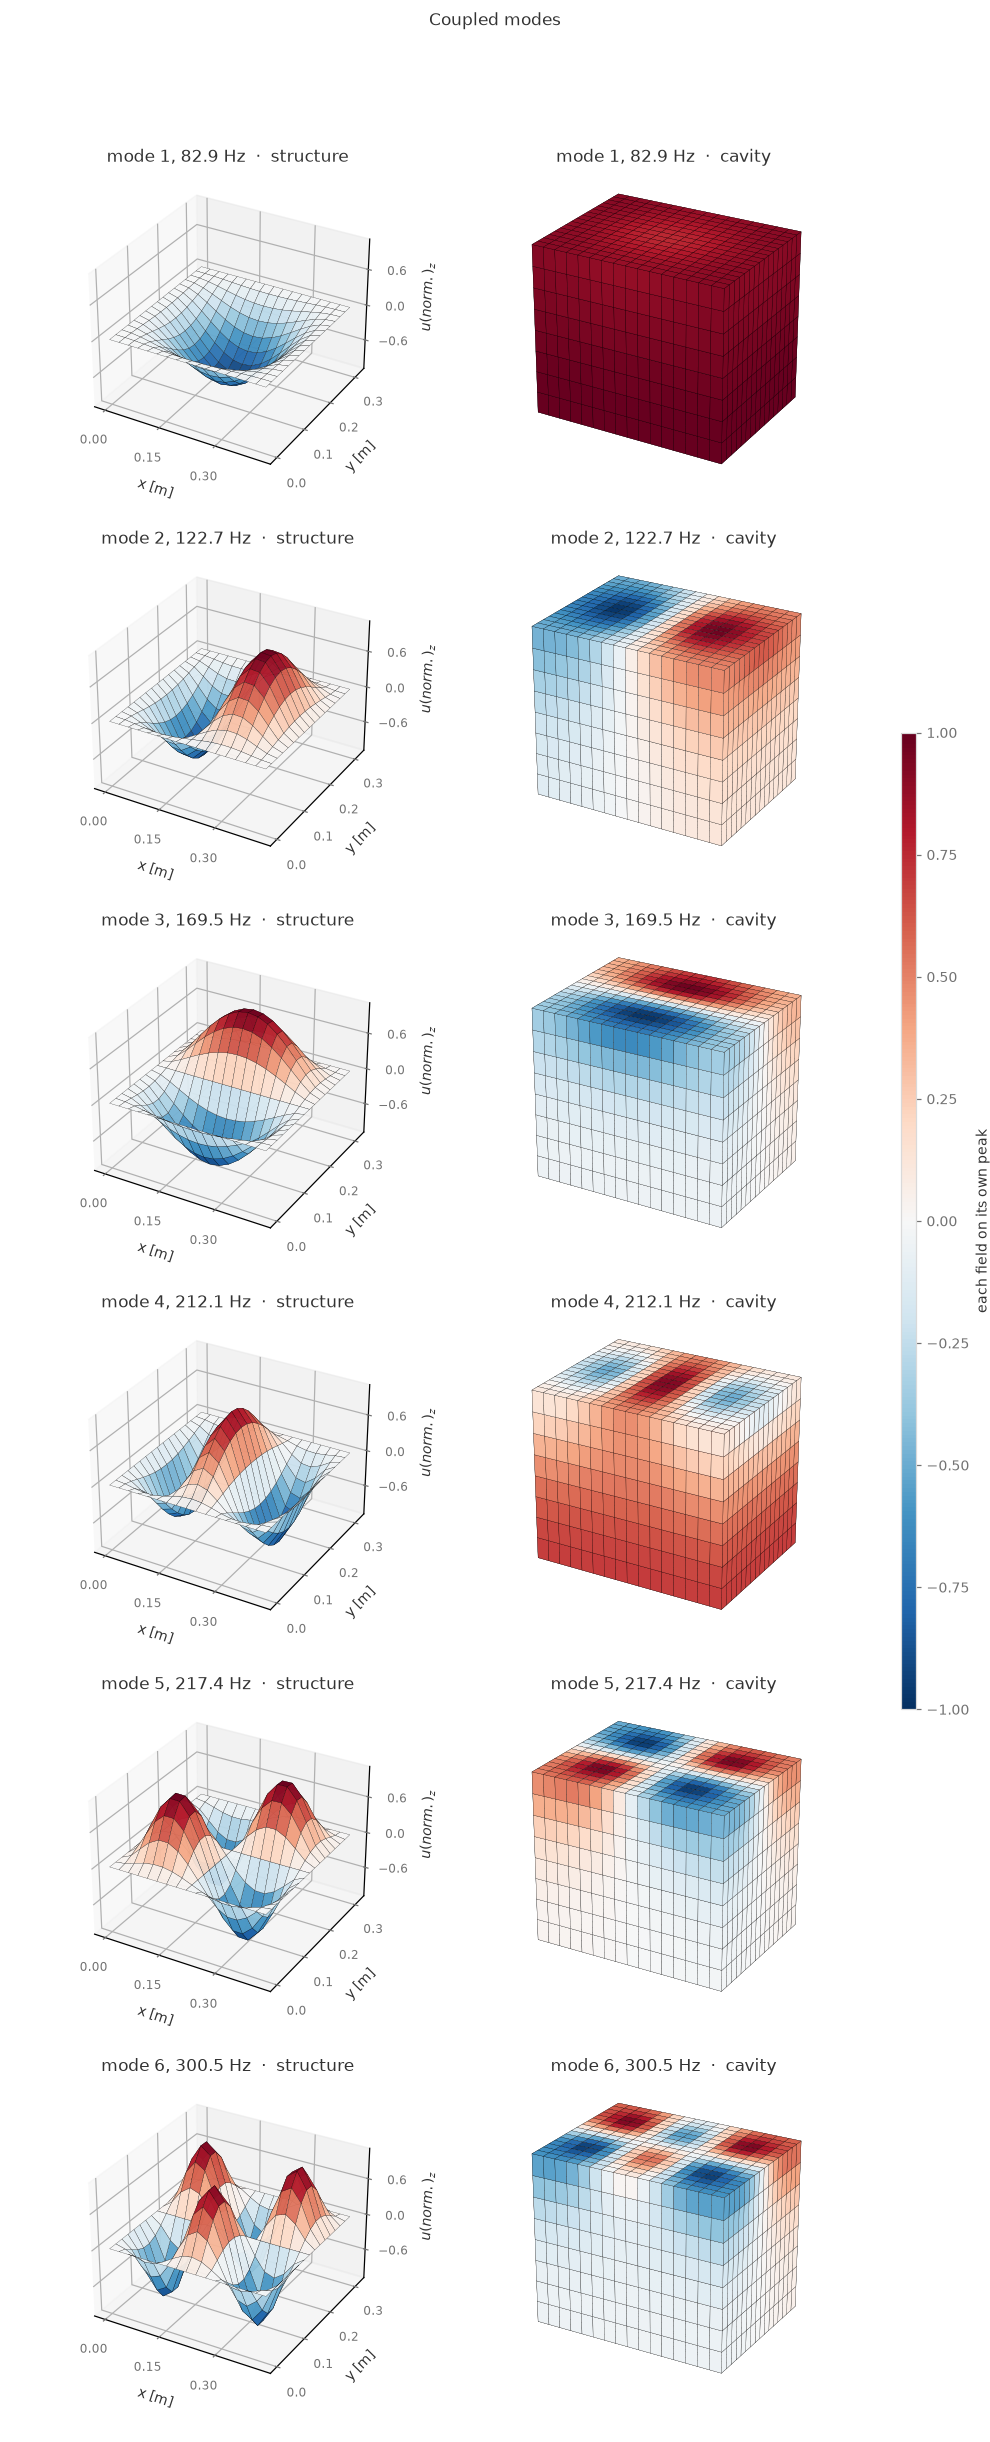

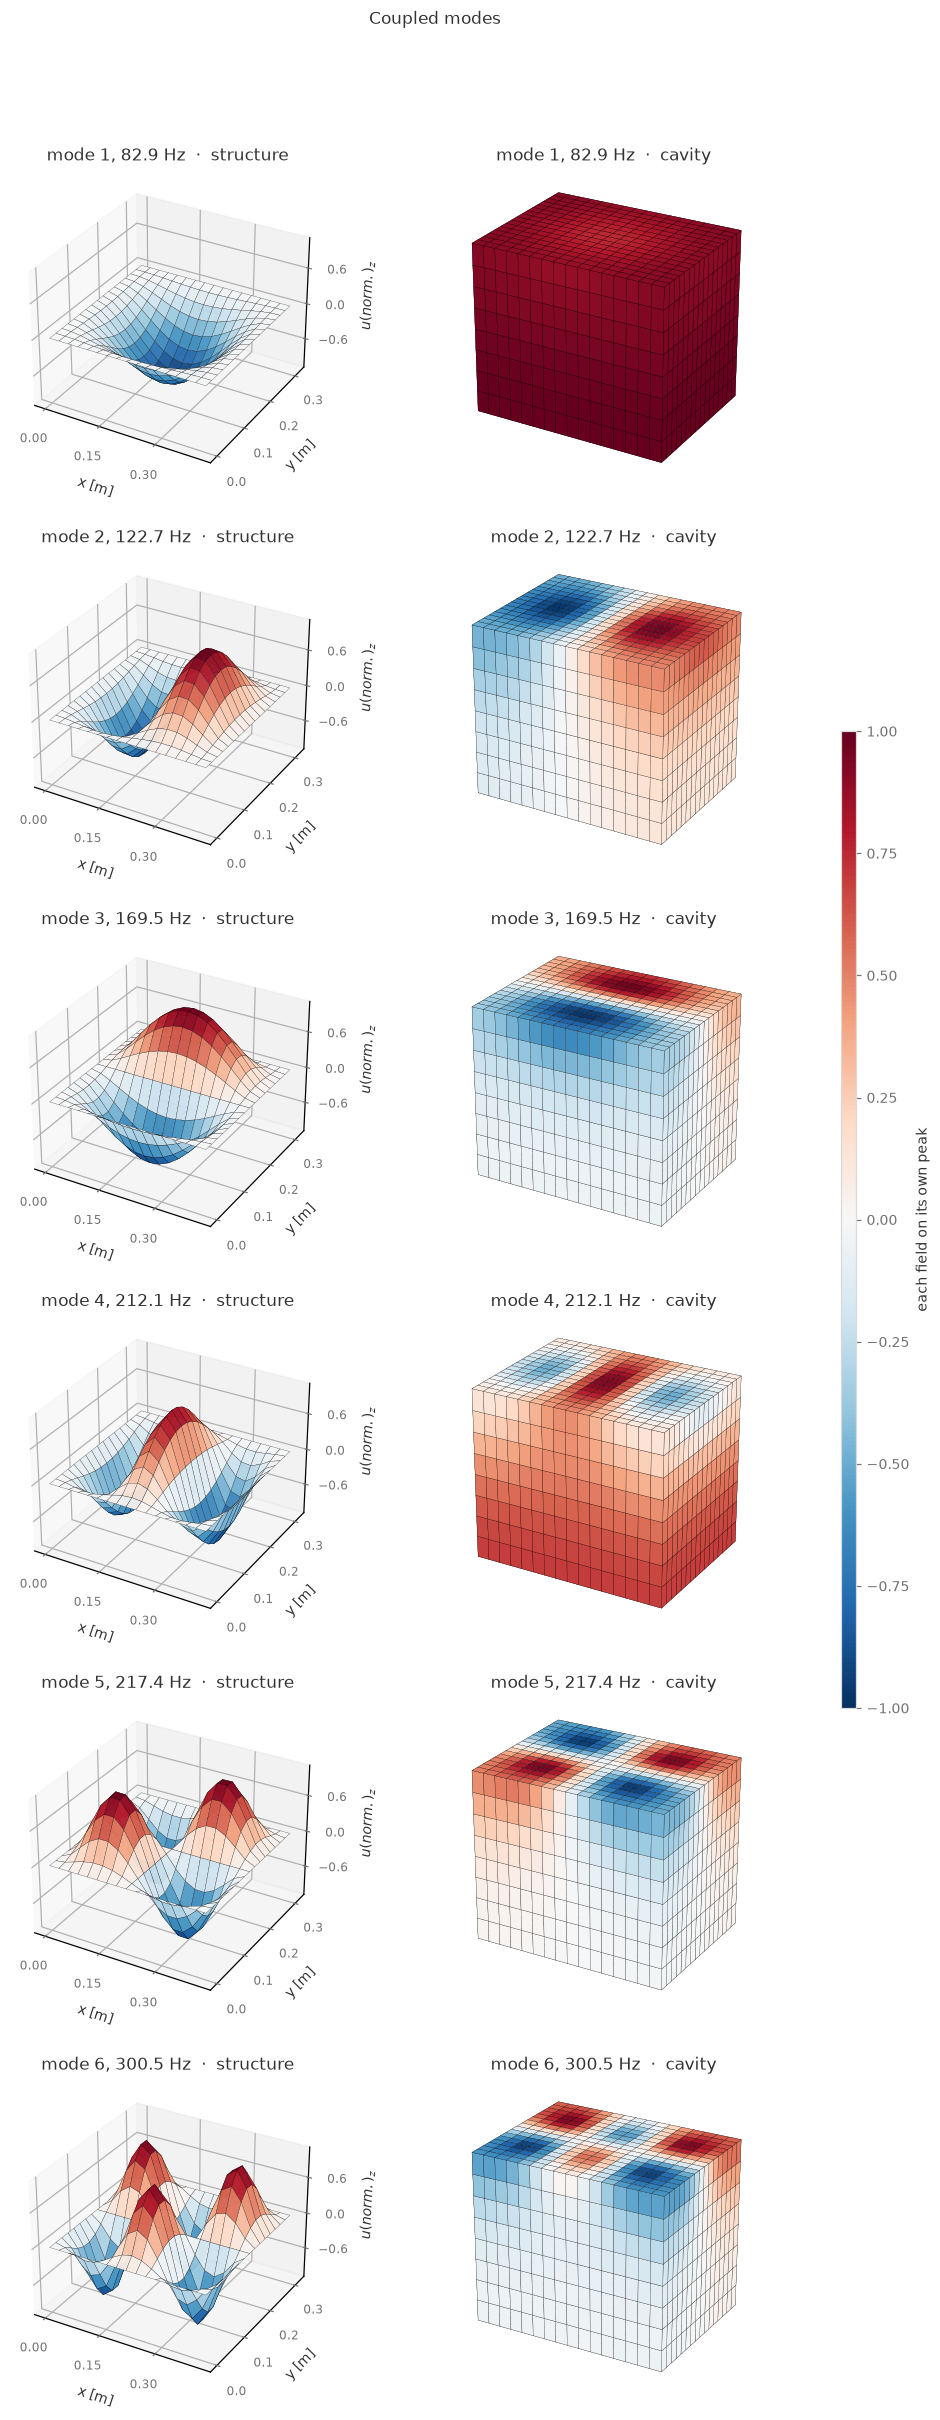

In [7]:
p_shapes = expand_pressure(shapes_coupled[blocks["n_s"]:],
                           blocks["idx_a"], nodes.shape[0])

plot_modes(model, f_coupled, p_shapes, structure_shapes=shapes_coupled,
           blocks=blocks, max_modes=6, title="Coupled modes", show=True)

---
## What to take away

* The geometry, the material **and the element counts** are the book's. On a
  comparison the mesh is part of the case, not a free choice.
* Check the two halves before coupling them: the plate against Warburton, the
  sealed cavity against its closed form. If either is wrong, every coupled
  frequency is wrong and nothing says so.
* $\mathbf K_c$ is the whole of the coupling, and its column sum is the
  interface area — 0.130 m² here, one line that catches a plate on the wrong
  face or a normal pointing inwards.
* $\mathbf A = \mathbf \Phi_s^{T}\mathbf K_c\mathbf \Phi_a$ says which plate
  mode talks to which cavity mode; its first column says which frequencies
  the air will stiffen.
* Air is a spring on the modes that compress it and added mass on the ones
  that do not: +13.6% on the first, about −1% on the rest.
* Match the two lists by **shape**, never by order.

The forced problem, the wall conditions and the reduced models are the
subject of `03_any_geometry_any_analysis.ipynb`.
